# LLM Trees - Decision Trees through LLMs

#### Members:
- Jasmine Jassi, 500970682
- Sam Olamazadeh, 500963965
- Tharindu(Tharu) Yakkala A. Don, 501220016
####  Emails:
- tyakkala@torontomu.ca
- jasmine.jassi@torontomu.ca
- sajjad.olamazadeh@torontomu.ca

# Introduction:

#### Problem Description:

This project aims to implement zero-shot prompting to generate decision-trees using a pre-trained LLM, namely Gemini 2.5 Flash, to observe how the model utilizes its world knowledge from pre-training for predictive modeling with 5 different datasets. This study follows the paper '"OH LLM, I'm Asking Thee, Please Give Me a Decision Tree": Zero-Shot Decision Tree Induction and Embedding with Large Language Models' by Knauer et. al.

#### Context of the Problem:

Training large language models, depending on the task and dataset at hand, can prove to be both computationally and literally expensive. In addition, with proprietary datasets, it can be a privacy issue to input sensitive details into public models, limiting the amount of data that can be used in training these models. Such a situation where data is scarce can be referred to as a "low-data regime" [1]. However, the general knowledge that these pre-trained models have can still be applicable or useful for generating models that can then be used for proprietary or smaller datasets, removing the issue for privacy as no training data is passed to the model; only feature names. The aspect of "knowledge distillation" to generate decision trees goes hand-in-hand with applying in-context learning, creating an approach to generate "intrinsically interpretable machine learning models" [1]. While the paper extends to embeddings analysis, this project focuses on the induction component (generating and evaluating the decision trees through zero-shot prompting).

#### Limitation About other Approaches:

Previous studies involved generating features without training data [1] and a few labeled examples [2] using LLMs. However, this project (and paper) focuses on building actual models that can be used to further interpret data without any training required.

#### Solution:

Rather than giving state-of-art LLMs access to proprietary data as examples, only important feature names are provided and the LLM is zero-shot prompted to create the best possible decision tree based on the knowledge it has. Similar to the paper, we use the decision trees to classify 5 different datasets and analyze the classification reports for accuray, precision and F1 values.

# Background

| Reference |Explanation |  Dataset/Input | Weakness |
|-----------|------------|----------------|----------|
| Nam et al. [2] | They proposed OCTree, a framework that uses LLMs to iteratively generate new column <br> features for tabular prediction tasks. <br> The LLM is prompted to return a feature name and generation rule <br> (using no training data in LLM prompt itself). <br> New feature used to augment data and combined data used to train decision tree. | Multiple tabular classification/regression benchmarks <br> (including Kaggle datasets); <br> CART algorithm and Llama 2 7B (fine-tuned) model | Evaluating generated features can be time-consuming if model requires <br> extensive training but the authors note this issue can be mitigated by <br> generating features with simpler prediction model first and then <br> using them in the target model |
| Han et al. [3] | They use FeatLLM (in-context learning framework) that uses LLMs to as feature engineers <br> to create optimal input dataset for tabular tasks. LLM is prompted with few labeled <br> examples and extracts rules associated with each class. The rules are used to create <br> binary features as inputs for a linear model to estimate likelihood of each class. | 13 different tabular datasets in low-shot regimes; <br> FeatLLM uses GPT-3.5 | Only generated binary features (limited representations); <br> Automated parsing via LLM error rates higher for data with many <br> categorical features; <br> Biases and misinformation embedded in the prior knowledge of LLMs should <br> be considered |
| Knauer et al. [1] | They use zero-shot prompting to generate decision trees without any training data. <br> They also create embeddings from these decision trees for <br> downstream models. | Small-sized tabular datasets from public Penn Machine <br> Learning Benchmarks (PMLB); <br> 4 state-of-the-art LLMs and 5 ML baselines | Focused on small-sized tabular datasets (question whether results <br> extend in other settings); <br> Used a simple prompting template (whether it captures all the complexity); <br> Can use more powerful LLMs (biases and prior knowledge of LLMs should be considered) <br> |


# Methodology

**Overview of Original Methodology**  
The methodology can be broken down into 2 parts as an overview:  
1. Zero-Shot Decision Tree Induction
Authors ask an LLM to generate a decision tree using only the feature names (column headers); no actual data values, no examples (zero-shot prompting). Then the LLM is used again to convert text-based decision tree into a Python function to be able to make predictions on data.  
→ LLM Models Used: Claude 3.5 Sonnet, Gemini 1.5 Pro, GPT-4o, GPT-o1  
→ Baseline Models Used: BSS, OCTs, AutoGluon, Auto-Prognosis, TabPFN
2. Zero-Shot Embedding Induction  
Using different baselines, more decision trees are generated and the structure is used to create an embedding of each data point. For a given sample, every internal decision node in the tree is a binary (0 or 1) value. The authors generate 5 diverse trees per LLM (temperature used to control variety) and concatenate all the node truth values into a single vector that is fed into a small NN with the original features for classification.   
→ LLM Models Used: Claude 3.5 Sonnet, Gemini 1.5 Pro, GPT-4o, GPT-o1  
→ Baseline Models Used: MLP with no embedding, Random trees embeddings, Extra trees embeddings, Random forests embeddings, XGboost embeddings 

Evaluation Metrics used: macro F1-score (3-fold cross validation), balanced accuracy (67%/33% train/test split)


**Overview of Our Methodology**  

This project follows BOTH the steps in the original paper. The difference only comes from:  
1. Models used; our project uses *gemma3, gpt_oss, mistral_small3, and qwen3* which were accessed through Ollama. 
2. For decision tree induction (part 1), we only applied 2 baseline models (AutoGluon, TabPFN) out of the 5 in the original paper due to accessibility; BSS, OCTs and Autoprognosis were not done. 
3. The original paper uses 15 datasets, we used 5.  

*All other process such as the decision tree induction and embedding induction stayed true to the original paper.*  


**Datasets**  

We used a select few datasets used by Knauer et al. (available on their official repository) that they note were less than or equal to 500 rows (small datasets). All datasets are classification based and have a binary target (0 or 1). The authors selected the datasets based off a certain criteria, including that the feature names be not ambiguous, could easily be understood by an LLM along with some descriptions of them, and an area of study where data-driven machines could require more effort to achieve good results (Knauer et al., 2025). The original paper uses 13 public and 2 private datasets. However, our project focuses on 5 of the datasets: bankruptcy.py, boxing1.py, boxing2.py, colic.py and creditscore.py.

**PART 1: Decision Tree Induction**  
We begin with prompting the LLMs (and baseline models) to create a decision tree classifier as a python function. We created a prompt using the same initial prompt used by Knauer et al, but a more simplified single prompt method. Our prompt can be found in `src/prompter.py`. 

The authors use prompting in both tree induction and embedding induction. In decision tree induction, the authors prompt an LLM multiple times to achieve 5 valid decision trees for each dataset. However, they note that the LLM first provides only the *structure* of the decision tree and therefore is prompted again to output a runnable python function (a python file of the decision tree classifier). This function is then used on the individual datasets for classification and calcualte metric scores. The authors set a maximum depth of 2 for tree induction prompts, which we replicate. This variation among the depth of the generated decision trees is controlled by *temperature*, which for this tree induction step is set to 0 (deterministic). Furthermore, there is *no training data* provided in the LLM prompt, only feature names. This aspect is not only good for proprietary datasets but also for reproducibility of code as the feature names are descriptive enough to give anyone a good idea of how the splits in the tree could happen. Our project streamlines the process of prompting for the structure and function in 2 steps that include embeddings as truth values (used in embedding induction). Examples of the prompted functions (decision tree classifier functions that were obtained by prompting the LLMs we chose) used in tree induction can be found in `data/data_sets/model_name/dataset_name/..` in our repository.  

The following figure shows the prompt template that the original paper uses:
<p align="center">
    <img src="src/figures/promptingtemplate.png"
    alt="original paper prompting template" width="500"/>
</p>
Sample output functions are provided in the Appendix for your reference. 


The following figure shows an extremely simplified process of how the decision trees are created. While the picture depicts Gemini Flash as the LLM, any other LLM suitable can be swapped for it:
<p align="center">
    <img src="src/figures/llm_flow.png" alt="LLM dt extraction flow" width="500"/>
</p>


While the prompts can induce different splits and hence differnt decision trees, the decision logic outputted by the LLM will remain consistent. Below is a figure detailing the simplified version of how each function works and an example output:
<p align="center">
    <img src="src/figures/func_example_full.png" alt="Function example" width="300"/>
</p>  

We also assess the ensemble capabilities by utilizing a voting style ensemble, where the final label is the most classified label.  

Here is a list of all the comparative/baseline models used for decision tree induction (note that the double asterisk means that our implementation for that model differs from the original paper's implementation):
* **LLMs
* TabPFN - AutoML/Deep Learning
* AutoGluon - AutoML/Deep Learning
* **BSS - Interpretable Model
* **OCTs - Interpretable Model
* **Autoprognosis - AutoML/Deep Learning
  

**PART 2: Embedding Induction**  
For embedding induction, prompting works the same way as for tree induction with one added step. The goal of this part is to create binary vector embeddings based on a generated decision tree structure (0 or 1 values in the embedding based on the node splits) for each sample in the data. Thus, the LLMs are again prompted for decision tree functions, but are also specified to return the embeddings when applied to the dataset. For the embedding generated, each value represents the internal node decisions of the tree. For example, a decision tree of depth 4, the embedding of a sample point might be (1, 1, 0). These embeddings are then fed to a multi-layer perceptron (MLP), which the original paper notes having one hidden layer. The number of neurons within the hidden layer are a changed to see how they influence the result of the neural network; the list of the number of neurons in the hidden layer tested include [10, 25, 50, 75, 100]. Additionally, we also analyze regularization strengths of [0.0001, 0.001, 0.01, 0.1] following the paper. The main evaluation scheme for embeddings can be found in `src/Evaluators/main_emb_eval.py` in our repository. 

Here is a figure from the original paper that depicts how an embedding can be created based on a decision tree:
<p align="center">
    <img src="src/figures/embeddingexample.png" alt="embedding example" width="500">
</p>  

There are a couple of differences in embedding induction compared to the simple decision tree induction. First, the baseline models are of course different. The baseline models for embedding induction are tree algorithms that differ in choices of how to split (compared to in part 1 where the paper simply looked at data-driven models that select the best possible classification given the dataset). Secondly, the paper states there is more freedom for the LLM to decide the depth of the decision tree created, rather than limiting it to a maximum of 2. In this case, the temperature is set to 1. 

The baseline used is a MLP with a single hidden layer with the *raw input values*, meaning a row from the original dataset. For other embeddings, the output is concatenated with the original raw values to create one large embedding vector. Then as usual the embeddings are applied to the downstream task. 3-fold cross validation is used for hyperparameter tuning and F1-scores over the 67%/33% test split that's repeated 5 times for the evaluation.

Here is a list of all the comparative/baseline models used for embedding induction: 
* LLM Embeddings
* Baseline - Uses the raw input values
* RandomTreeEmbeddings
* RandomTrees - Supervised
* RandomTrees - SemiSupervised
* ExtraTrees - Supervised
* ExtraTrees - Semisupervised
* XGBoost - Supervised
* XGBoost - Semisupervised  


# Implementation

**Also Requires Ollama software**

https://ollama.com/download/windows

### Decision Tree Induction

The extraction is done through Ollama.

We use the following models:
* gpt-oss:20b
* qwen3:14B
* gemma3:12b
* mistral-small3.2:24b

These are chosen because they easily fit into 16GB VRAM

**NOTE**: Execution might take a while so we provide the sample outputs

For both decision tree induction, and embedding trees, we instead combine the decision tree step and the function step into a unified chain of thought reasoning prompt.  

**NOTE**: For decision tree induction, only TabPFN and AutoGluon are implemented as aforementioned. This is due to accessibility issues (some of these models require a license) as well as time out issues (model taking an extremely long time to run).  

We begin decision tree induction by prompting and saving the decision tree functions outputted by the models. Then we go into evaluation and plot the results of each model for each dataset based on their F1-score.  
**Make sure to check requirements.txt in the repository before running the code as some of the following cells require those dependencies** (ex. may request one-time API key for TabPFN). 

In [1]:
from src.prompter import generate_all_prompts, get_dt_functions_out

In [2]:
induction_prompts = generate_all_prompts(datasets_path="./data/data_sets", embeddings=False)


Generating DTs for each dataset: 100%|██████████| 5/5 [00:00<00:00, 2535.55it/s]


In [3]:
# Generates the dt induction for each model.
# Since outputs exists already, this will run fast
get_dt_functions_out(prompts=induction_prompts, output_path="./data/llm_induction", temperature=0, dt_trees=1)

Generateing dt functions from each model: 100%|██████████| 4/4 [00:00<00:00, 2622.67it/s]

Runing gpt-oss:20b
Runing qwen3:14B
Runing gemma3:12b
Runing mistral-small3.2:24b


**Sample output**

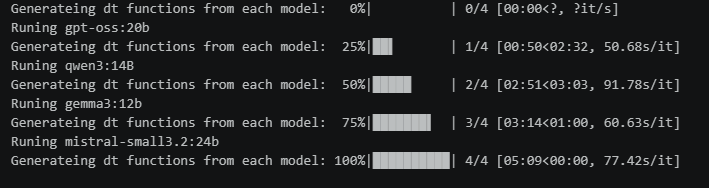

### Induction Evaluation

In [1]:
from src.llm_induction_eval.main_ind_eval import evaluate_ind_dataset
from src.plotter import plot_emb_results

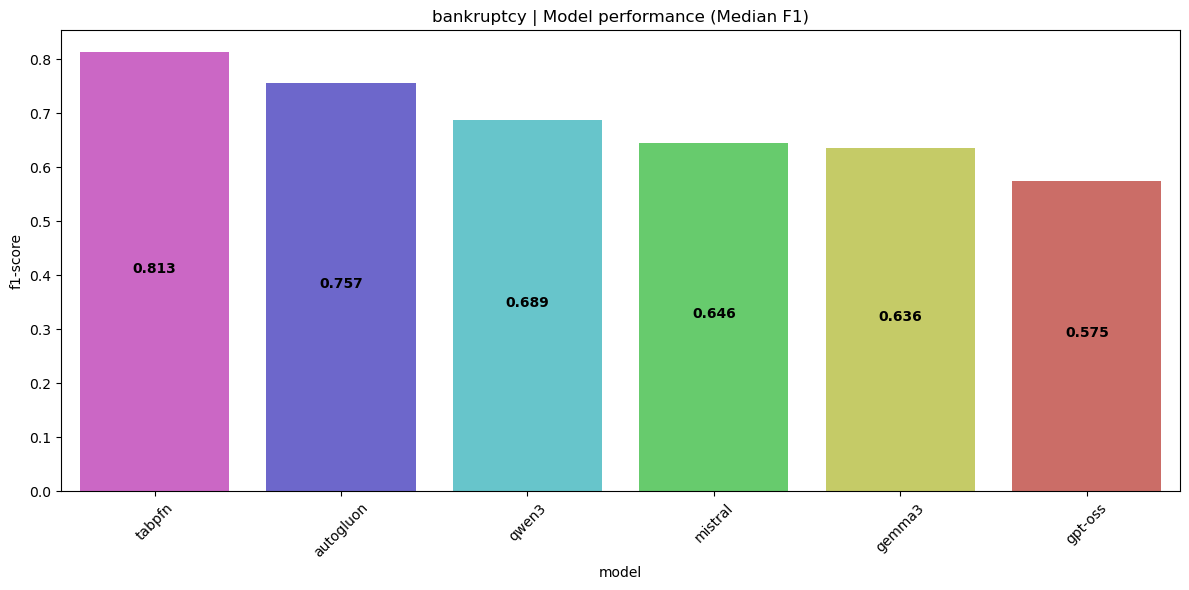

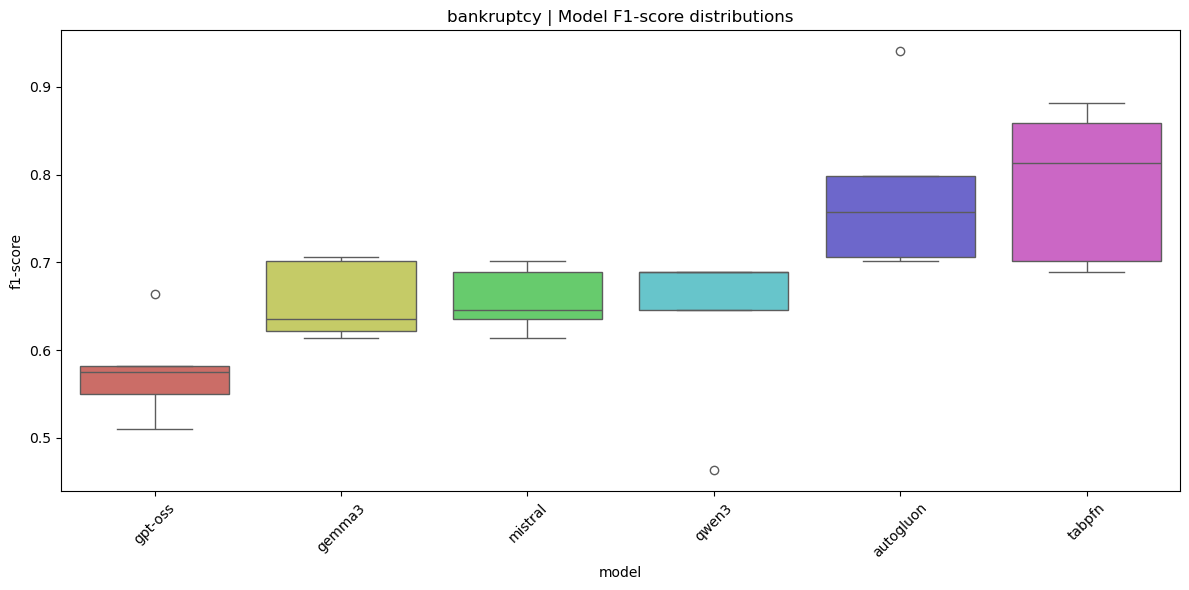

In [2]:
# Bankruptcy
dataset = "bankruptcy"
results = evaluate_ind_dataset(dataset)
plot_emb_results(results=results, dataset=dataset)

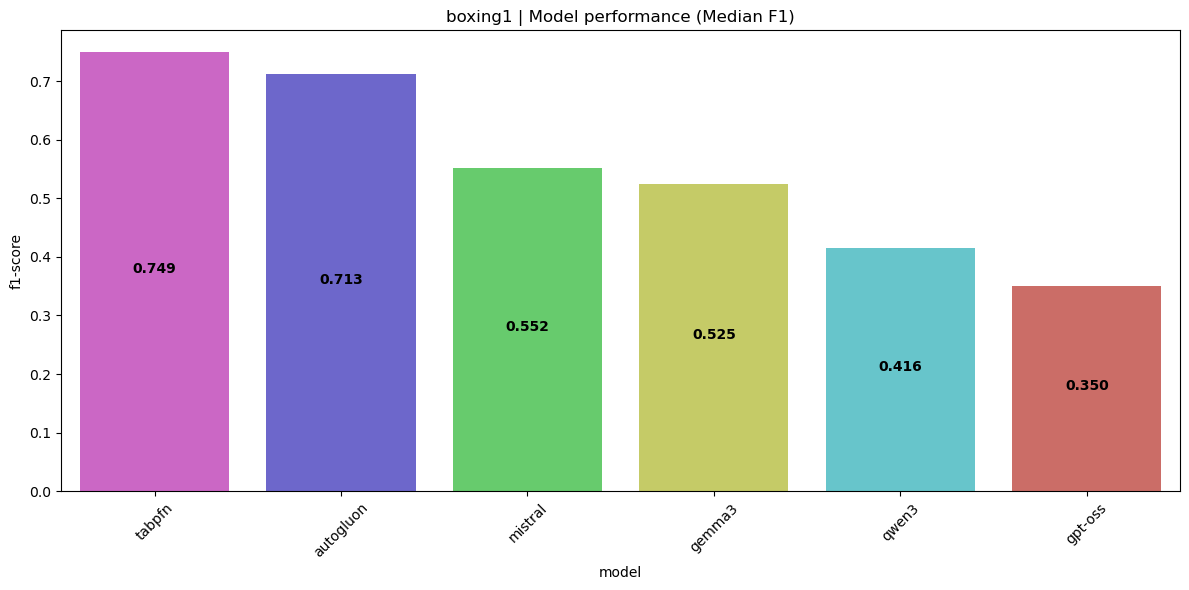

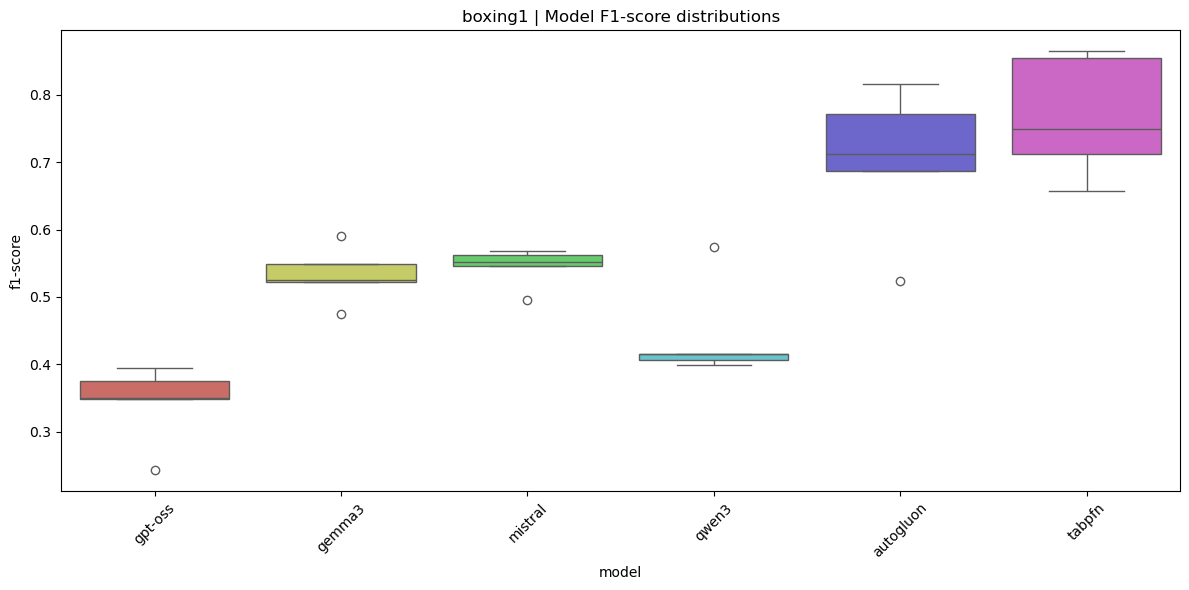

In [3]:
# Boxing1
dataset = "boxing1"
results = evaluate_ind_dataset(dataset)
plot_emb_results(results=results, dataset=dataset)

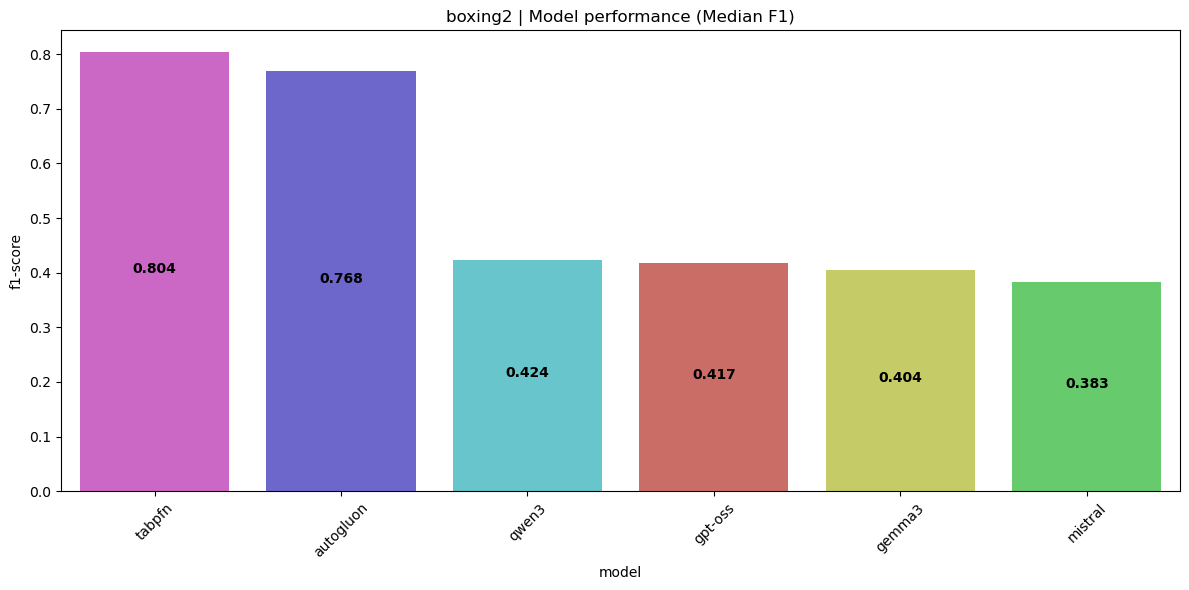

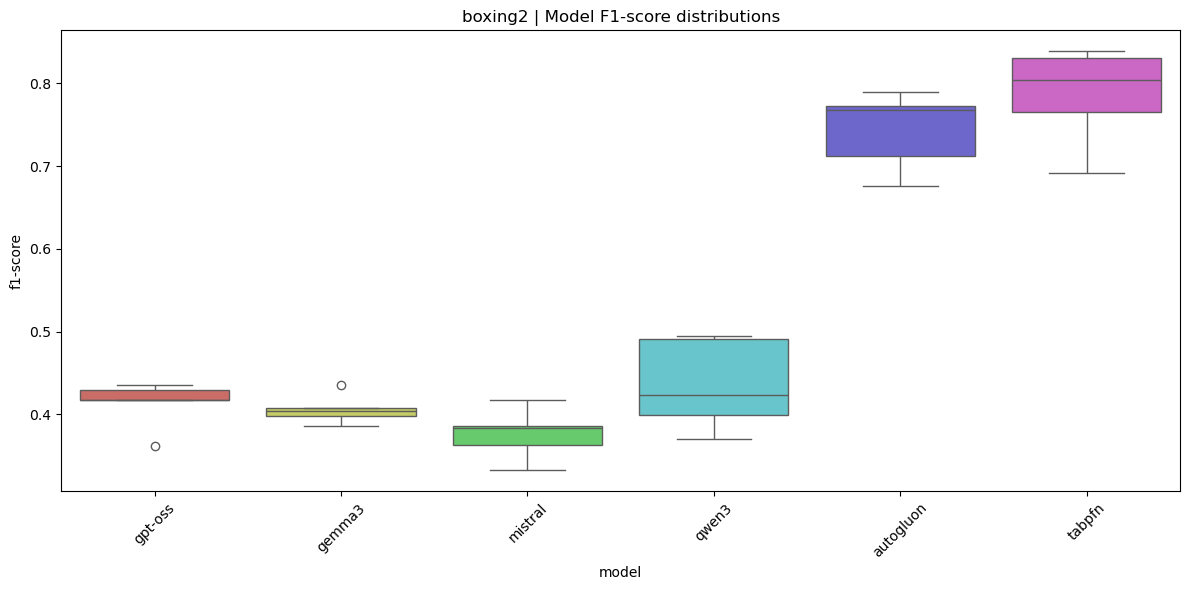

In [4]:
# Boxing2
dataset = "boxing2"
results = evaluate_ind_dataset(dataset)
plot_emb_results(results=results, dataset=dataset)

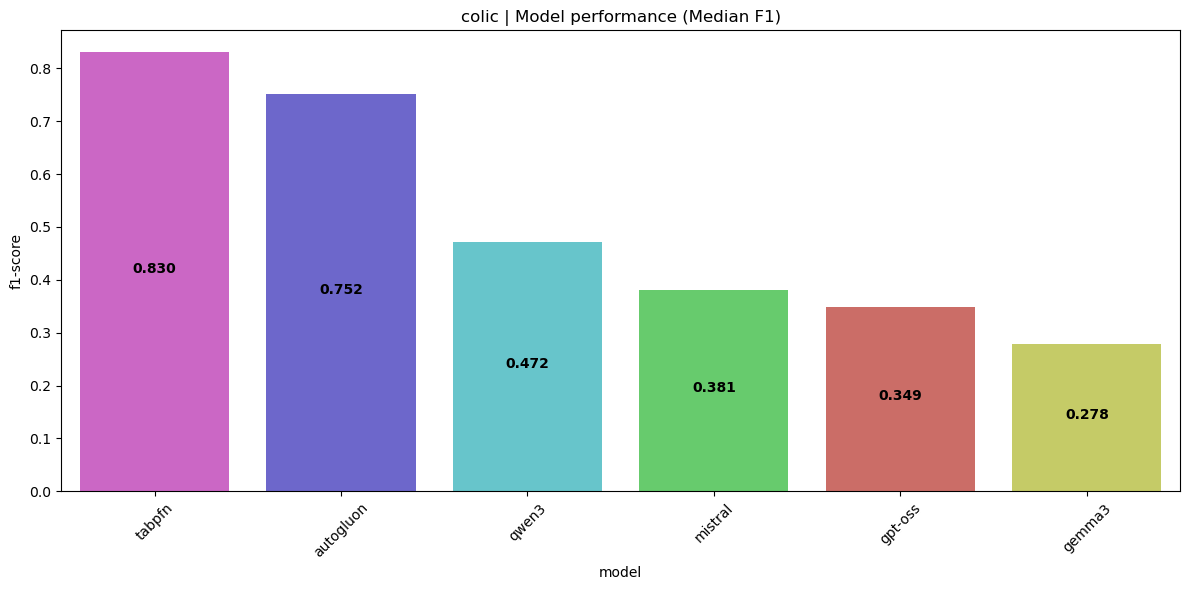

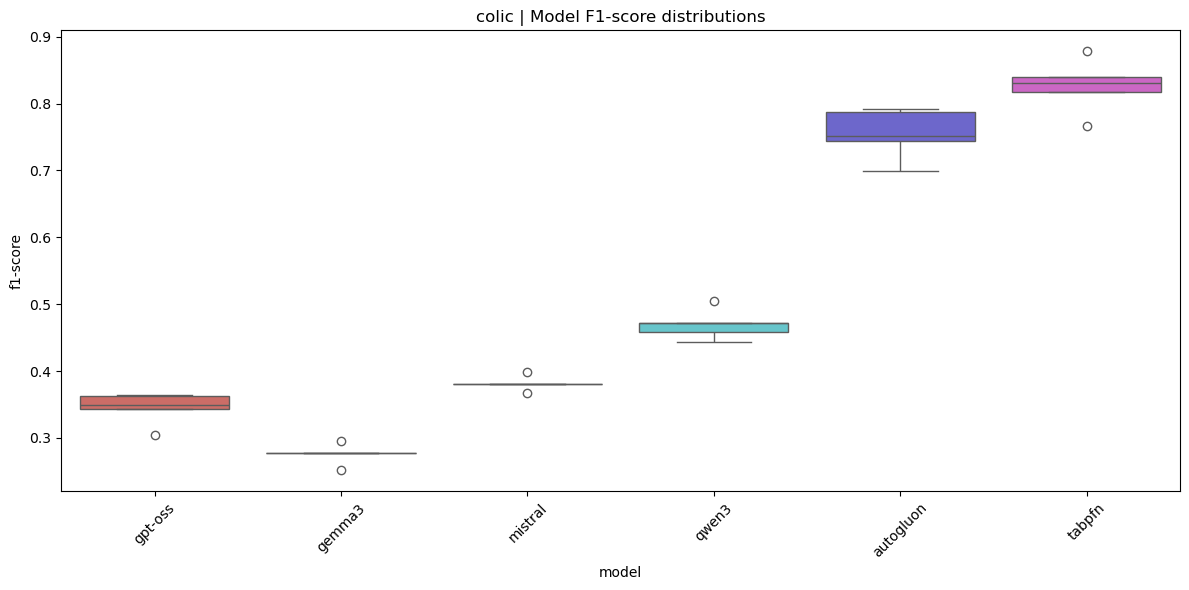

In [5]:
# Colic
dataset = "colic"
results = evaluate_ind_dataset(dataset)
plot_emb_results(results=results, dataset=dataset)

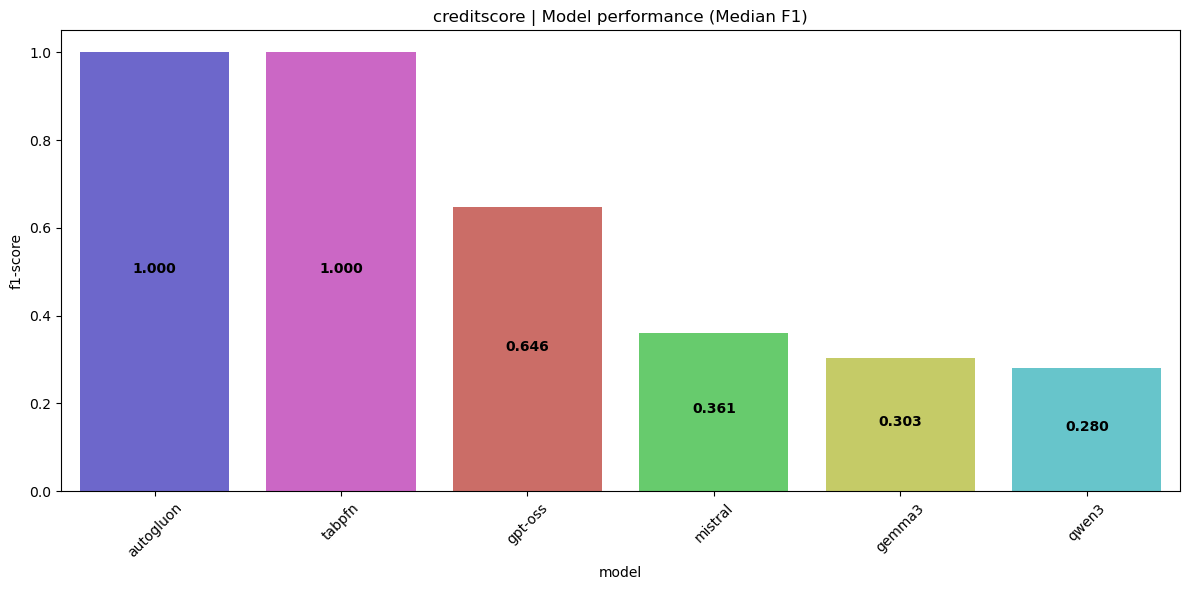

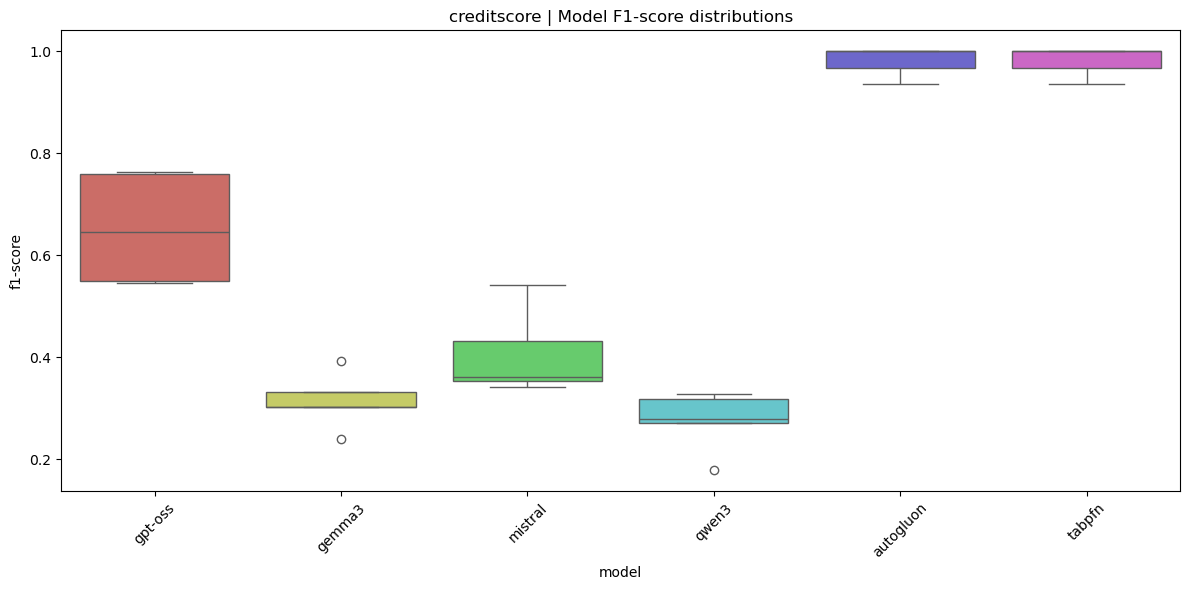

In [6]:
# Creditscore
dataset = "creditscore"
results = evaluate_ind_dataset(dataset)
plot_emb_results(results=results, dataset=dataset)

In [7]:
## NOTE This cell will take 2-3mins to run
import os
import pandas as pd

os.makedirs("./data/results/induction", exist_ok=True)

datasets = ["bankruptcy", "boxing1", "boxing2", "colic", "creditscore"]
all_results = []
for dataset in datasets:
    df = evaluate_ind_dataset(dataset)
    df["dataset"] = dataset
    df.to_csv(f"./data/results/induction/{dataset}_results.csv", index=False)
    all_results.append(df)

all_df = pd.concat(all_results, ignore_index=True)
summary = (
    all_df.groupby(["dataset", "model"])["f1-score"]
    .median()
    .reset_index()
    .pivot(index="dataset", columns="model", values="f1-score")
    .round(3)
)
col_order = ["gemma3", "mistral", "gpt-oss", "qwen3", "autogluon", "tabpfn"]
summary = summary[col_order]
summary["median"] = summary.median(axis=1).round(2)
summary.index.name = "dataset"
summary.to_csv("./data/results/induction/summary.csv")
summary

model,gemma3,mistral,gpt-oss,qwen3,autogluon,tabpfn,median
dataset,,,,,,,
bankruptcy,0.636,0.646,0.575,0.689,0.757,0.813,0.67
boxing1,0.525,0.552,0.350,0.416,0.713,0.749,0.54
boxing2,0.404,0.383,0.417,0.424,0.768,0.804,0.42
colic,0.278,0.381,0.349,0.472,0.752,0.830,0.43
creditscore,0.303,0.361,0.646,0.280,1.000,1.000,0.50


### Decision Tree Embedding

For Decision Tree Embedding we fully implement all their embedding extraction models

* baseline
* RandomTreesEmbedding
* RandomForest (both supervised and self-supervised)
* ExtraTrees (both supervised and self-supervised)
* XGboost (both supervised and self-supervised)

**Final Classifer**

Multilayer Perceptron from scikit learn using 3-fold cross validation, using the same grid parameters as the original methodology.

**MODEL LEGEND**

This will help understanding the plots.
* baseline  = raw features from the dataset
* rf = RandomForest
* et = ExtraTrees
* rt = RandomTreeEmbeddings
* s = supervised
* ss = semi-supervised

In [ ]:
embedding_prompts = generate_all_prompts(datasets_path="./data/data_sets", embeddings=True)

Generating DTs for each dataset: 100%|██████████| 5/5 [00:00<00:00, 1446.81it/s]


In [ ]:
# Generates the LLM Embedding induction for each model. So 5 decision trees per model, for each dataset
# Since outputs exists already, this will run fast
get_dt_functions_out(prompts=embedding_prompts, output_path="./data/llm_embeddings", temperature=1.0, dt_trees=5)

Generateing dt functions from each model: 100%|██████████| 4/4 [00:00<00:00, 1469.49it/s]

Runing gpt-oss:20b
Runing qwen3:14B
Runing gemma3:12b
Runing mistral-small3.2:24b


**Sample output**

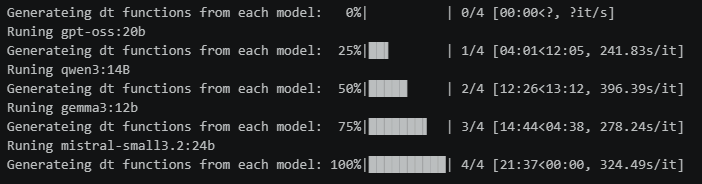

### Embedding Evaluation

In [ ]:
# Embedding Evaluation
from src.llm_embedding_eval import evaluate_emb_dataset
from src.plotter import plot_emb_results

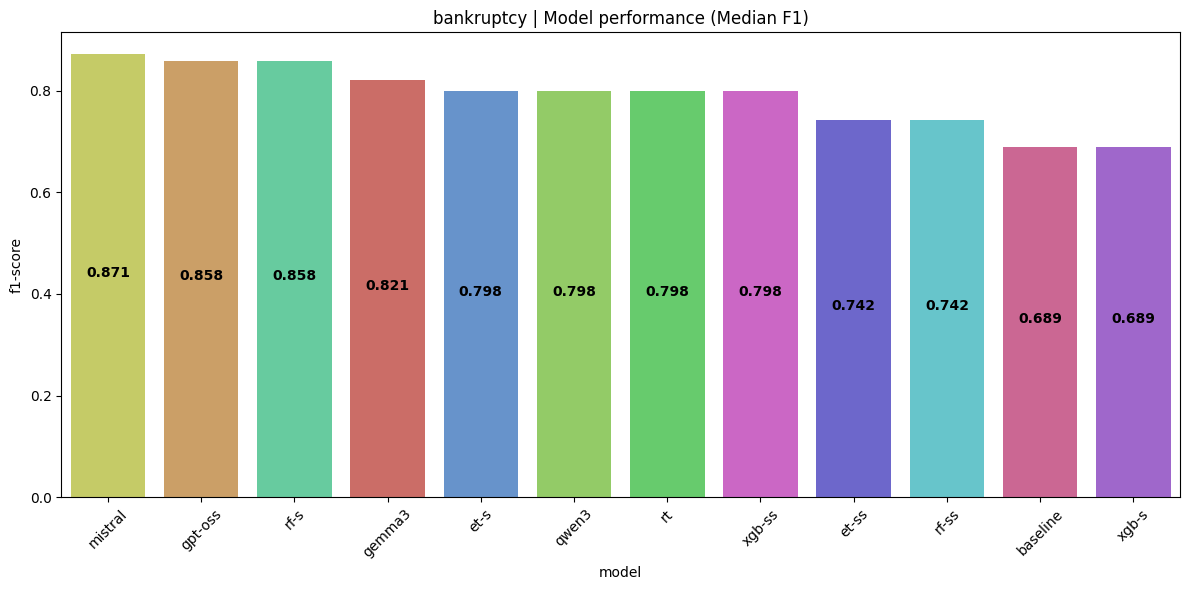

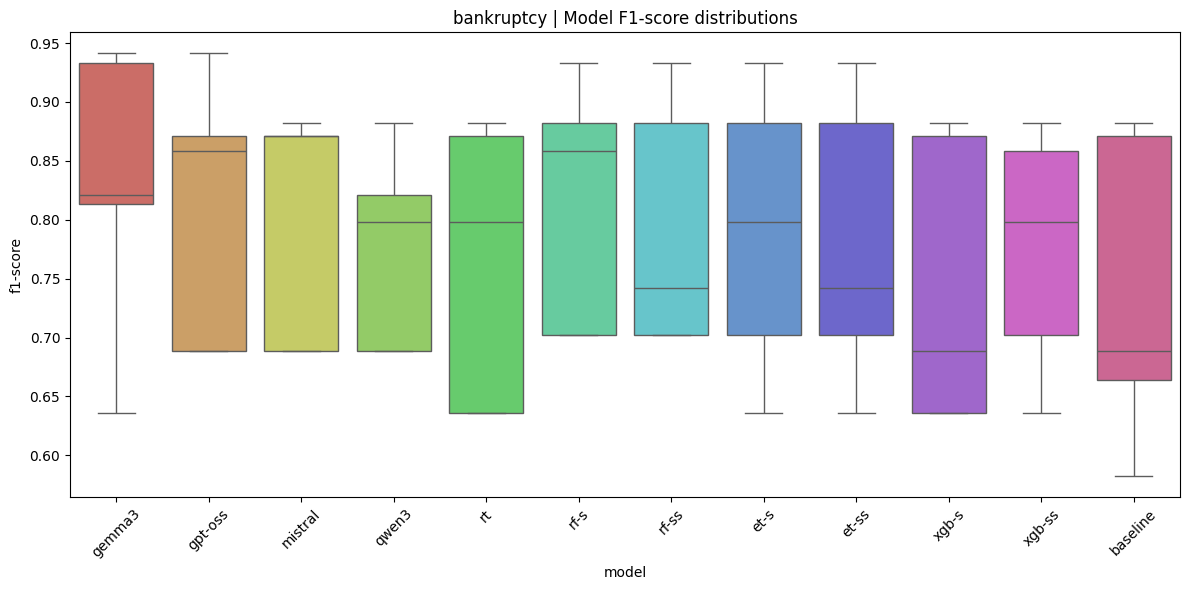

In [ ]:
# Bankruptcy
dataset = "bankruptcy"
results = evaluate_emb_dataset(dataset)
plot_emb_results(results=results, dataset=dataset)

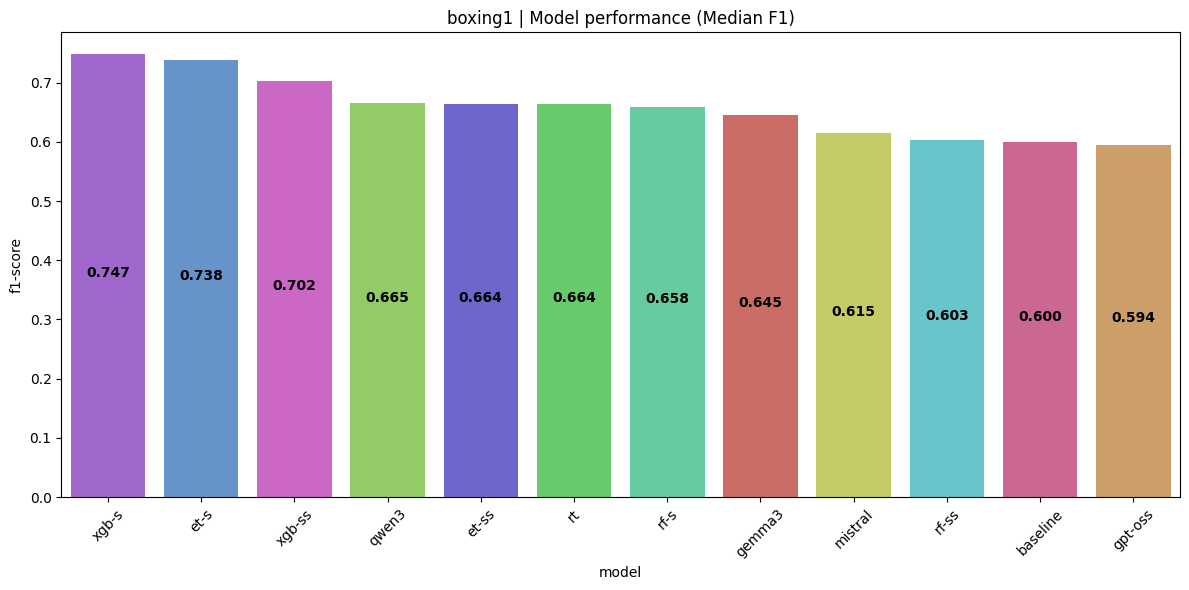

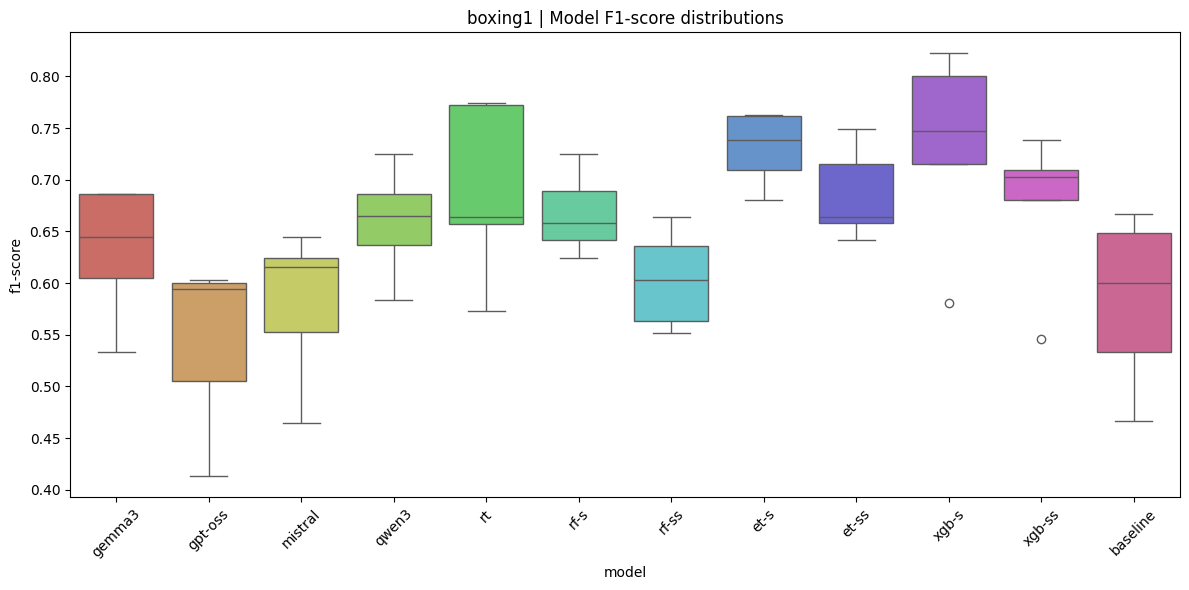

In [ ]:
# Boxing1
dataset = "boxing1"
results = evaluate_emb_dataset(dataset)
plot_emb_results(results=results, dataset=dataset)

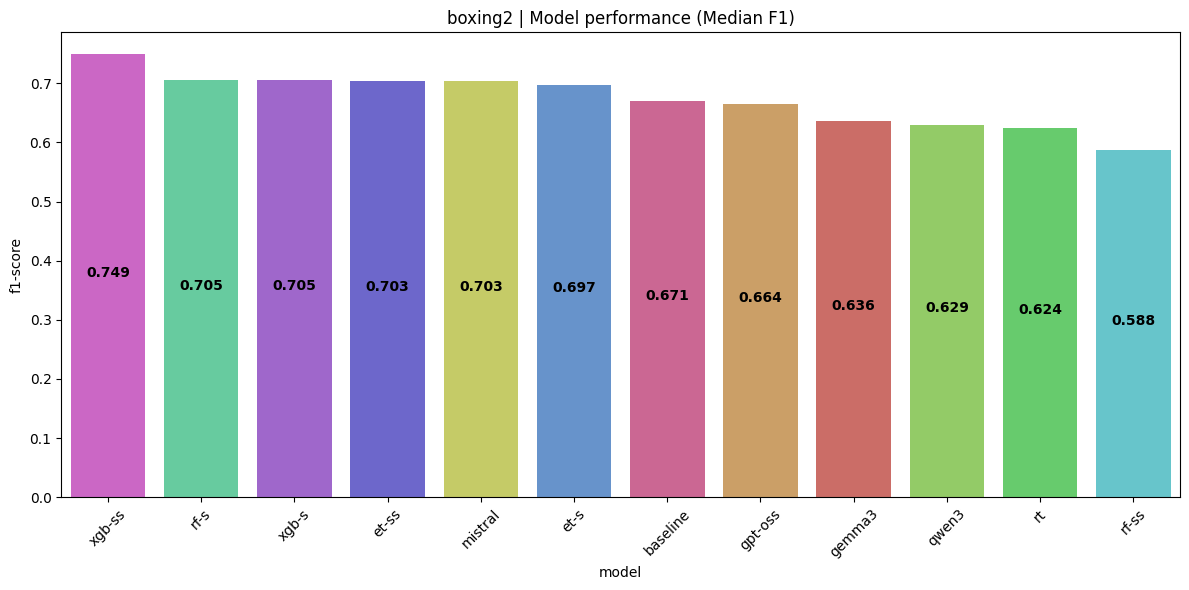

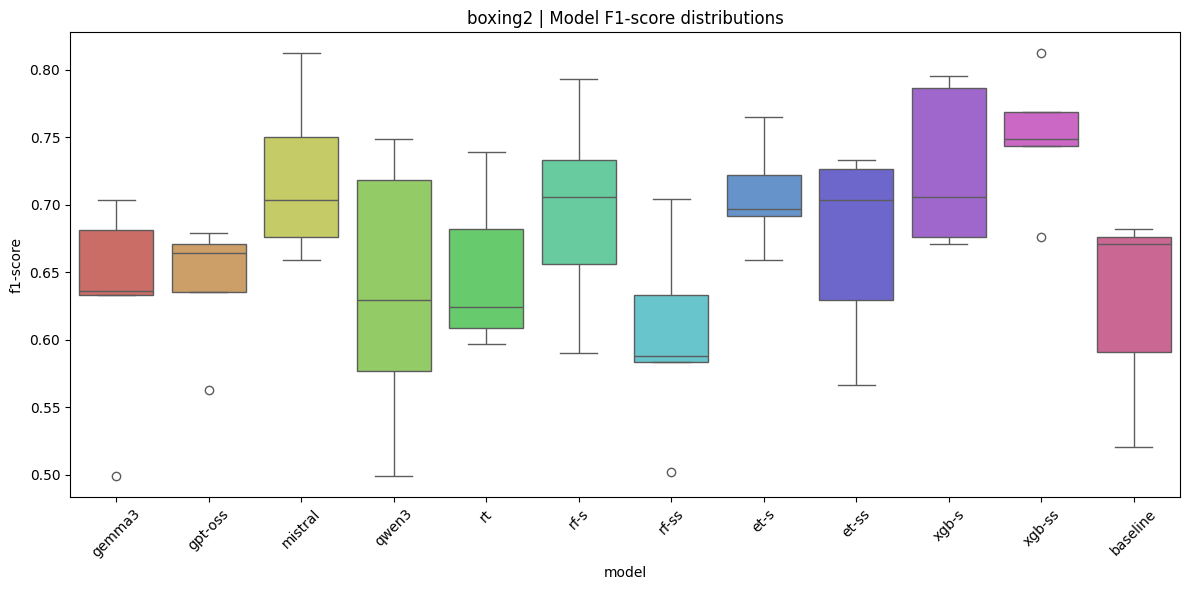

In [ ]:
# Bankruptcy
dataset = "boxing2"
results = evaluate_emb_dataset(dataset)
plot_emb_results(results=results, dataset=dataset)

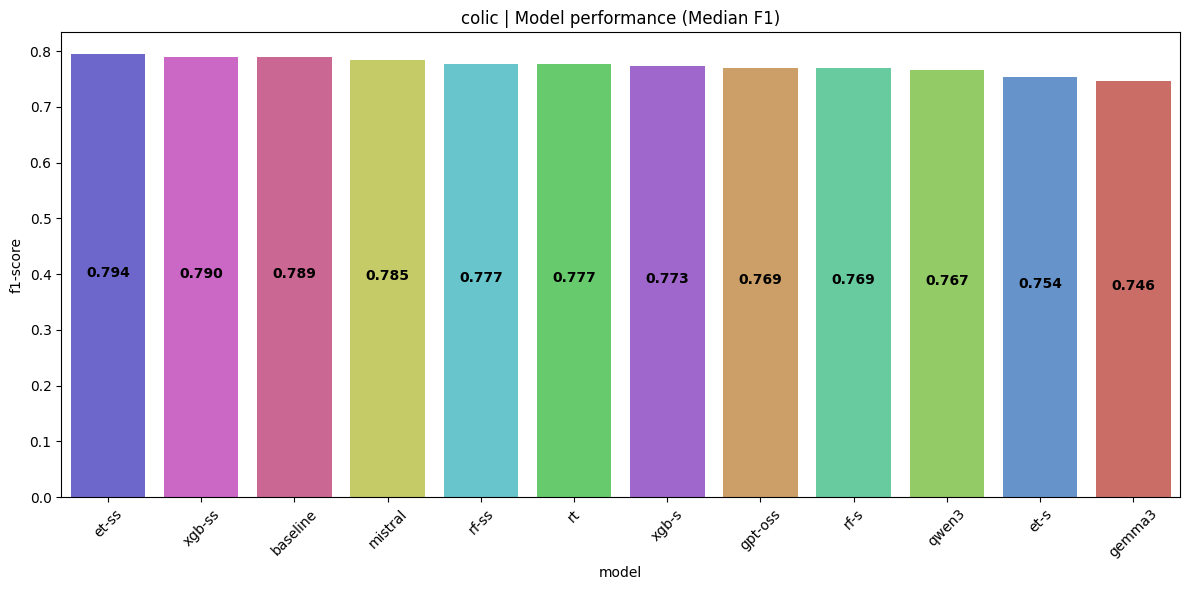

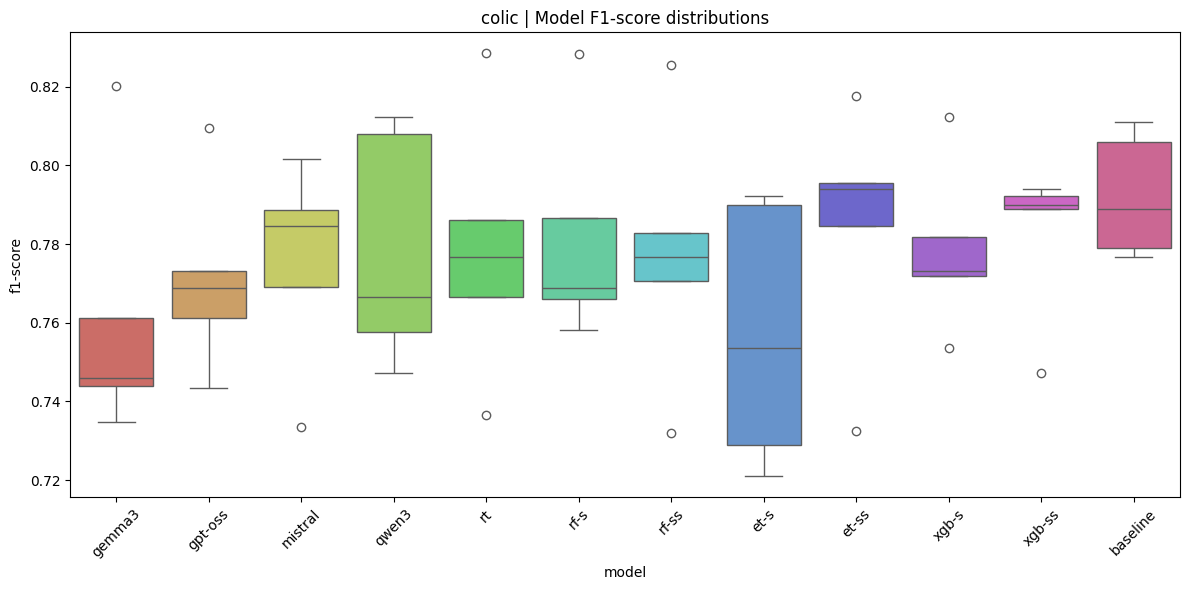

In [ ]:
# Bankruptcy
dataset = "colic"
results = evaluate_emb_dataset(dataset)
plot_emb_results(results=results, dataset=dataset)

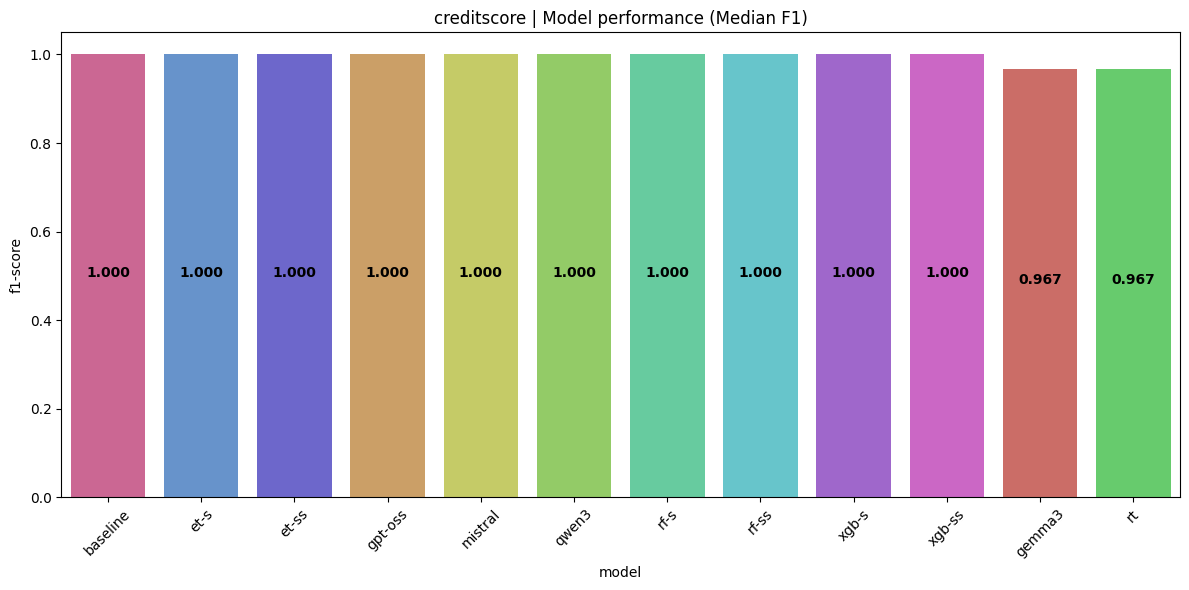

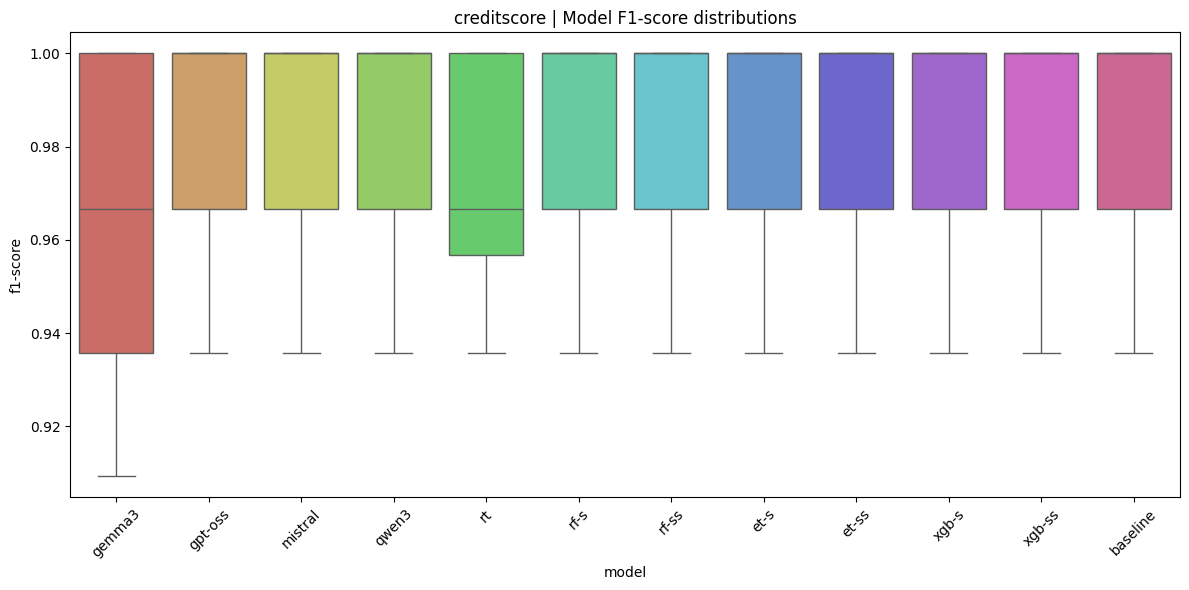

In [ ]:
# Bankruptcy
dataset = "creditscore"
results = evaluate_emb_dataset(dataset)
plot_emb_results(results=results, dataset=dataset)

In [9]:
## NOTE This will take 2-3 min to run
import os
import pandas as pd
from src.llm_embedding_eval.main_emb_eval import evaluate_emb_dataset

os.makedirs("./data/results/embedding", exist_ok=True)

datasets = ["bankruptcy", "boxing1", "boxing2", "colic", "creditscore"]
all_results = []
for dataset in datasets:
    df = evaluate_emb_dataset(dataset)
    df["dataset"] = dataset
    df.to_csv(f"./data/results/embedding/{dataset}_results.csv", index=False)
    all_results.append(df)

all_df = pd.concat(all_results, ignore_index=True)
summary = (
    all_df.groupby(["dataset", "model"])["f1-score"]
    .median()
    .reset_index()
    .pivot(index="dataset", columns="model", values="f1-score")
    .round(2)
)

baseline = summary["baseline"]

col_order = [
    "baseline", 
    "gemma3", "mistral", "gpt-oss", "qwen3", 
    "rt", 
    "et-ss", "rf-ss", "xgb-ss", 
    "et-s", "rf-s", "xgb-s"
    ]
summary = summary[col_order]
summary["median"] = summary.median(axis=1).round(2)
summary.index.name = "dataset"
summary.to_csv("./data/results/embedding/summary.csv")
summary

model,baseline,gemma3,mistral,gpt-oss,qwen3,rt,et-ss,rf-ss,xgb-ss,et-s,rf-s,xgb-s,median
dataset,,,,,,,,,,,,,
bankruptcy,0.69,0.82,0.87,0.86,0.80,0.80,0.74,0.74,0.80,0.80,0.86,0.69,0.80
boxing1,0.60,0.64,0.62,0.59,0.66,0.66,0.66,0.60,0.70,0.74,0.66,0.75,0.66
boxing2,0.67,0.64,0.70,0.66,0.63,0.62,0.70,0.59,0.75,0.70,0.71,0.71,0.68
colic,0.78,0.77,0.78,0.79,0.79,0.78,0.78,0.76,0.78,0.77,0.79,0.77,0.78
creditscore,1.00,0.97,1.00,1.00,1.00,0.97,1.00,1.00,1.00,1.00,1.00,1.00,1.00


# Conclusion and Future Direction

Looking at the graphs for part 1 decision tree inductions, it is visible that most of the time the data-driven models perform better than the decision tree classifiers generated by the LLMs. In particular, TabPFN performs the best often. The Qwen3 LLM is often the best performing LLM among the 4 used but it performs the worst for the creditscore dataset. This might point back to the "world knowledge" that certain LLMs have, and whether there is a large disparity among these LLMs in terms of what domain they have more world knowledge in. However that thought could apply to all other models in terms of how well they perform: if a certain model has more knowledge about a certain domain, it will probably have more "context" to learn better and therefore give more accurate results. Among the datasets, the bankruptcy dataset had the most even results among all the models, and the least difference between the best and worst performing model. The resulting table for part 1 reflects these results accordingly with the F1 scores. 

For part 2 embedding induction, there are some interesting results as the embeddings from the LLMs in some cases actually provided better F1-scores than their baseline counterparts such as in the bankruptcy dataset where mistral and gpt-oss ranked 1st and 2nd respectively. However, in the other cases the comparative models like XGBoost outperform the LLMs; providing a mix of results and not a clear implication of whether overall the embeddings from LLMs perform better as while one model may rank very high for one dataset, it may rank last for another. One interesting dataset is the creditscore dataset which in part 1, only the data-driven models did primarily well but in part 2 using embeddings, almost all models achieve a f1-score = 1.0. This might support the idea that embeddings and neural networks would be a better representation of the data for such tasks or domains, as the lowest scoring models in any dataset in part 2 embedding induction are always performing better than the lowest scoring models in part 1 decision tree induction.

Whether the findings of this project supports the findings of the original paper is not a clear yes as there are limitations that primarily revolve around the number of datasets (and their sizes) in addition to the models used that differ from the actual paper itself. Knauer et al. use a larger number of datasets (13-15) while we used 5. This may affect generalizeability in the results as we know that models often struggle with less data. In addition, we were not able to use all the models in part 1 decision tree induction as mentioned in our methodology overview due to accessibility issues. Being able to use these models and also more similar models to the ones used in the paper might reflect more similar results. 



# References:

[1]:  Knauer, R., Koddenbrock, M., Wallsberger, R., Brisson, N. M., Duda, G. N., Falla, D., Evans, D. W., & Rodner, E. (2025). “Oh LLM, I’m Asking Thee, Please Give Me a Decision Tree”: Zero-Shot Decision Tree Induction and Embedding with Large Language Models. Proceedings of the 31st ACM SIGKDD Conference on Knowledge Discovery and Data Mining V.2, 1196–1206. https://doi.org/10.1145/3711896.3736818


[2]:  Jaehyun Nam, Kyuyoung Kim, Seunghyuk Oh, Jihoon Tack, Jaehyung Kim, andJinwoo Shin. 2024. Optimized Feature Generation for Tabular Data via LLMswith Decision Tree Reasoning. Advances in neural information processing systems37 (2024). doi:10.48550/arXiv.2406.08527. https://doi.org/10.48550/arXiv.2406.08527

[3]:  Sungwon Han, Jinsung Yoon, Sercan Ö Arik, and Tomas Pfister. 2024. Large Language Models Can Automatically Engineer Features for Few-Shot Tabular Learning. In Proceedings of the 41st International Conference on Machine Learning (ICML).PMLR, Vienna, Austria, 17454–17479. https://doi.org/10.48550/arXiv.2404.09491


# Appendix

## A.1: Comparison Table of Our Implementation vs Original Paper Implementation
The following table shows the key differences between our implementation and the original paper implementation.  
  

#### Table A.1: Implementation Comparison Table
| Experiment | Original Paper | Our Paper | Rough Overlap % |
|-----------|------------|----------------|----------|
| Part 1: decision tree induction | <u>Models Used:</u> Claude 3.5 Sonnet, Gemini 1.5 Pro, GPT-4o, GPT-o1, <br> BSS, OCTs, Auto-Gluon ✅, Auto-Prognosis, TabPFN ✅ <br><br> <u>Methodology:</u> <br> Prompt models to generate decision trees with only feature names (5 *valid* decision trees per dataset), <br> Prompt again to transform the decision tree structure into an executable python file <br> Assess each function on each dataset  | <u>Models Used:</u> Mistral, Qwen3, Gpt-oss, Gemma3, <br> Auto-Gluon, TabPFN <br><br> <u>Methodology:</u> <br> Prompt models to generate decision trees with only feature names (5 *valid* decision trees per dataset) along with <br>  functions and embeddings (streamlined into less steps) <br> Assess each function on each dataset | 90% (only real difference is models used) |
| Part 2: Embedding Induction | <u>Models Used:</u> Claude 3.5 Sonnet, Gemini 1.5 Pro, GPT-4o, GPT-o1, <br> Baseline - Uses the raw input values <br> RandomTreeEmbeddings <br> RandomTrees - Supervised <br> RandomTrees - SemiSupervised <br> ExtraTrees - Supervised <br> ExtraTrees - Semisupervised <br> XGBoost - Supervised <br> XGBoost - Semisupervised   <br><br> <u>Methodology:</u> <br> Prompt models to generate decision trees with only feature names and get python functions that return <br> embeddings for each sample data point <br> Concatenate embeddings (if not baseline model) and feed into MLP <br> Assess F1-scores | <u>Models Used:</u> Mistral, Qwen3, Gpt-oss, Gemma3, <br> Baseline - Uses the raw input values <br> RandomTreeEmbeddings <br> RandomTrees - Supervised <br> RandomTrees - SemiSupervised <br> ExtraTrees - Supervised <br> ExtraTrees - Semisupervised <br> XGBoost - Supervised <br> XGBoost - Semisupervised   <br><br> <u>Methodology:</u> <br> Prompt models to generate decision trees with only feature names and get python functions that return <br> embeddings for each sample data point <br> Concatenate embeddings (if not baseline model) and feed into MLP <br> Assess F1-scores | 100% (matches paper implementation fully) |

  
  
<br>  


## A.2: Decision Tree Induction: Function Output
The following is an example of two decision tree classifier (python functions) output by an LLM (based on the structure of the decision tree it generated first):
```python
def predict_bankruptcy(features):
    """
    Predicts if a telecommunications firm will go bankrupt based on financial ratios.

    Args:
        features (dict): A dictionary containing the following financial ratios:
            'Working Capital/Total Assets' (float, percentage)
            'Retained Earnings/Total Assets' (float, percentage)
            'Earnings Before Interest and Tax/Total Assets' (float, percentage)
            'Sales/Total Assets' (float, percentage)
            'Book Value of Equity/Book Value of Liabilities' (float)

    Returns:
        tuple: A tuple containing:
            - int: The prediction (1 for Bankrupt, 0 for Non-Bankrupt).
            - list: A list of truth values (1 if condition satisfied, 0 otherwise)
                    for the inner nodes traversed.
    """
    # Extract features using the exact names provided
    wc_ta = features['Working Capital/Total Assets']
    # re_ta = features['Retained Earnings/Total Assets'] # Not used in this specific tree
    ebit_ta = features['Earnings Before Interest and Tax/Total Assets']
    # s_ta = features['Sales/Total Assets'] # Not used in this specific tree
    bve_bvl = features['Book Value of Equity/Book Value of Liabilities']
    ...
```

```python
def classify_telecom_bankruptcy(WC_TA, RE_TA, EBIT_TA, S_TA, BVE_BVL):
    """
    Classifies a telecommunications firm as 'Bankrupt' or 'Not Bankrupt'
    based on financial ratios, using a depth-2 decision tree.

    Features (all expressed as percentages or ratios):
    WC_TA (Working Capital/Total Assets)
    RE_TA (Retained Earnings/Total Assets)
    EBIT_TA (Earnings Before Interest and Tax/Total Assets)
    S_TA (Sales/Total Assets)
    BVE_BVL (Book Value of Equity/Book Value of Liabilities)

    Returns:
    - prediction (str): 'Bankrupt' or 'Not Bankrupt'
    - truth_values (list): A list of 1s and 0s representing the truth values
                          of the inner node conditions.
                          Index 0: BVE_BVL <= 0.1
                          Index 1: EBIT_TA <= -10
                          Index 2: WC_TA <= 0
    """
    
    # Initialize truth values for all inner nodes to 0.
    # The order corresponds to: [Node 0: BVE_BVL, Node 1: EBIT_TA, Node 2: WC_TA]
    truth_values = [0, 0, 0] 
    ...
```